In [1]:
import os, random, json, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                              f1_score, roc_curve)
from scipy.stats import mannwhitneyu, entropy as scipy_entropy
from scipy.special import softmax as scipy_softmax

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "| GPU count:", torch.cuda.device_count())

OUT_DIR = "/kaggle/working/davisnet_xai_uq"
os.makedirs(OUT_DIR, exist_ok=True)

Device: cuda | GPU count: 2


In [19]:
TRAIN_DIR = '/kaggle/input/datasets/nafeesalmahadi/oct2026-retinal-oct2017-balanced-701515-split/OCT2026/train_balanced'
VAL_DIR   = '/kaggle/input/datasets/nafeesalmahadi/oct2026-retinal-oct2017-balanced-701515-split/OCT2026/val_balanced'
TEST_DIR  = '/kaggle/input/datasets/nafeesalmahadi/oct2026-retinal-oct2017-balanced-701515-split/OCT2026/test_balanced'

MODEL_PATH = '/kaggle/input/models/varunsiddharthkaza/best-cbam-vgg16-ds/pytorch/default/1/best_cbam_vgg16_ds.pt'

CLASSES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
IMG_SIZE = 224
BATCH_SIZE = 32
DROPOUT_RATE = 0.4

MC_PASSES = 50          # MC Dropout stochastic forward passes
XAI_SAMPLE_SIZE = 100   # per-class subsample cap for quantitative XAI (set to None for full test set)
DRUSEN_IDX = CLASSES.index('DRUSEN')

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [20]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, ratio=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // ratio),
            nn.ReLU(inplace=True),
            nn.Linear(channels // ratio, channels)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.shape
        avg_out = self.mlp(self.avg_pool(x).view(b, c))
        max_out = self.mlp(self.max_pool(x).view(b, c))
        attn = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * attn

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        attn = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * attn

class CBAM(nn.Module):
    def __init__(self, channels, ratio=8, kernel_size=7):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, ratio)
        self.spatial_attn = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_attn(x)
        x = self.spatial_attn(x)
        return x

class CBAM_VGG16_DS(nn.Module):
    def __init__(self, num_classes=len(CLASSES), dropout_rate=DROPOUT_RATE):
        super().__init__()
        vgg = models.vgg16(weights=None)   # weights loaded from checkpoint, not ImageNet, here
        features = vgg.features

        self.block1_2 = features[0:10]
        self.block3_4 = features[10:24]
        self.block5   = features[24:31]

        for p in self.block1_2.parameters():
            p.requires_grad = False

        self.cbam1 = CBAM(512)
        self.cbam2 = CBAM(512)

        self.aux_pool = nn.AdaptiveAvgPool2d(1)
        self.aux_fc = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

        self.main_pool = nn.AdaptiveAvgPool2d(1)
        self.main_fc = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, return_features=False):
        x = self.block1_2(x)
        x = self.block3_4(x)
        block4_feat = self.cbam1(x)

        x = self.block5(block4_feat)
        block5_feat = self.cbam2(x)

        aux = self.aux_pool(block4_feat).flatten(1)
        aux_out = self.aux_fc(aux)

        main = self.main_pool(block5_feat).flatten(1)
        main_out = self.main_fc(main)

        if return_features:
            return main_out, aux_out, block4_feat, block5_feat
        return main_out, aux_out


model = CBAM_VGG16_DS().to(device)
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()
print("Loaded DAVis-Net checkpoint.")

Loaded DAVis-Net checkpoint.


In [4]:
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

# ImageFolder sorts classes alphabetically — remap to your CLASSES order and VERIFY this printout
imgfolder_classes = test_dataset.classes
print("ImageFolder class order:", imgfolder_classes)
remap = {imgfolder_classes.index(c): CLASSES.index(c) for c in CLASSES}
test_dataset.samples = [(p, remap[l]) for p, l in test_dataset.samples]
test_dataset.targets = [remap[l] for l in test_dataset.targets]

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

all_labels = np.array(test_dataset.targets)
all_paths  = np.array([p for p, _ in test_dataset.samples])
print("Test set size:", len(test_dataset), "| Class counts:", np.bincount(all_labels))

ImageFolder class order: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Test set size: 12650 | Class counts: [5614 1734 1321 3981]


### Part A: Uncertainty Analysis

In [5]:
def enable_mc_dropout(m):
    """Set only nn.Dropout layers to train mode; everything else (BatchNorm etc.) stays in eval."""
    if isinstance(m, nn.Dropout):
        m.train()

model.eval()
model.apply(enable_mc_dropout)  # call this after every model.eval() before MC inference

CBAM_VGG16_DS(
  (block1_2): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3_4): Sequential(
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel

In [6]:
@torch.no_grad()
def run_mc_dropout(model, loader, n_passes=MC_PASSES):
    model.eval()
    model.apply(enable_mc_dropout)

    all_probs = []  # shape: [n_passes, N, num_classes]
    for t in range(n_passes):
        pass_probs = []
        for x, _ in loader:
            x = x.to(device, non_blocking=True)
            main_out, _ = model(x)
            probs = F.softmax(main_out, dim=1).cpu().numpy()
            pass_probs.append(probs)
        all_probs.append(np.concatenate(pass_probs, axis=0))
        if (t + 1) % 10 == 0:
            print(f"MC pass {t+1}/{n_passes} done")
    return np.stack(all_probs, axis=0)  # [T, N, C]

mc_probs = run_mc_dropout(model, test_loader, MC_PASSES)
np.save(os.path.join(OUT_DIR, "mc_probs.npy"), mc_probs)
print("mc_probs shape:", mc_probs.shape)

MC pass 10/50 done
MC pass 20/50 done
MC pass 30/50 done
MC pass 40/50 done
MC pass 50/50 done
mc_probs shape: (50, 12650, 4)


In [7]:
mean_probs = mc_probs.mean(axis=0)              # [N, C]
pred_class = mean_probs.argmax(axis=1)          # [N]
confidence = mean_probs.max(axis=1)             # [N]
correct = (pred_class == all_labels)

# Predictive entropy: H[mean(p)]
entropy_pred = -np.sum(mean_probs * np.log(mean_probs + 1e-12), axis=1)

# Expected entropy: mean over passes of H[p_t]
per_pass_entropy = -np.sum(mc_probs * np.log(mc_probs + 1e-12), axis=2)  # [T, N]
expected_entropy = per_pass_entropy.mean(axis=0)                          # [N]

# Mutual information (epistemic uncertainty) = predictive entropy - expected entropy (BALD)
mutual_info = entropy_pred - expected_entropy

# Variation ratio: 1 - (fraction of passes agreeing with the modal class)
per_pass_pred = mc_probs.argmax(axis=2)          # [T, N]
mode_pred = pred_class                            # using mean-prob argmax as the "mode" reference
agree_frac = (per_pass_pred == mode_pred[None, :]).mean(axis=0)
variation_ratio = 1 - agree_frac

# Std of the predicted (mean-argmax) class's probability across passes
std_predicted_class = np.array([
    mc_probs[:, i, pred_class[i]].std() for i in range(len(pred_class))
])

uq_df = pd.DataFrame({
    "path": all_paths,
    "true_class": [CLASSES[i] for i in all_labels],
    "pred_class": [CLASSES[i] for i in pred_class],
    "Correct": correct,
    "Confidence": confidence,
    "Entropy": entropy_pred,
    "Variation_Ratio": variation_ratio,
    "Mutual_Information": mutual_info,
    "STD_Predicted_Class": std_predicted_class,
})
uq_df.to_csv(os.path.join(OUT_DIR, "davisnet_uncertainty_per_sample.csv"), index=False)
uq_df.head()

,path,true_class,pred_class,Correct,Confidence,Entropy,Variation_Ratio,Mutual_Information,STD_Predicted_Class
0,/kaggle/input/datasets/nafeesalmahadi/oct2026-...,CNV,CNV,True,0.991819,0.051598,0.0,0.001334,0.004117
1,/kaggle/input/datasets/nafeesalmahadi/oct2026-...,CNV,CNV,True,0.980441,0.101015,0.0,0.001876,0.007888
2,/kaggle/input/datasets/nafeesalmahadi/oct2026-...,CNV,CNV,True,0.973823,0.134380,0.0,0.003586,0.011346
3,/kaggle/input/datasets/nafeesalmahadi/oct2026-...,CNV,CNV,True,0.982994,0.095127,0.0,0.003676,0.010032
4,/kaggle/input/datasets/nafeesalmahadi/oct2026-...,CNV,CNV,True,0.984753,0.087095,0.0,0.002539,0.008514


In [8]:
metrics = ["Confidence", "Entropy", "Variation_Ratio", "Mutual_Information", "STD_Predicted_Class"]

correct_incorrect_summary = uq_df.groupby("Correct")[metrics].mean().reset_index()
print(correct_incorrect_summary)
correct_incorrect_summary.to_csv(os.path.join(OUT_DIR, "correct_vs_incorrect_summary.csv"), index=False)

sig_results = []
for m in metrics:
    grp_correct = uq_df.loc[uq_df.Correct, m]
    grp_incorrect = uq_df.loc[~uq_df.Correct, m]
    stat, p = mannwhitneyu(grp_incorrect, grp_correct, alternative="two-sided")
    sig_results.append({"Metric": m, "Statistic": stat, "P_Value": p})

sig_df = pd.DataFrame(sig_results)
sig_df.to_csv(os.path.join(OUT_DIR, "significance_tests.csv"), index=False)
print(sig_df)

   Correct  Confidence   Entropy  Variation_Ratio  Mutual_Information  \
0    False    0.729133  0.562275         0.038900            0.006276   
1     True    0.952147  0.175375         0.000514            0.004168   

   STD_Predicted_Class  
0             0.034871  
1             0.014822  
                Metric  Statistic        P_Value
0           Confidence   266441.0  1.482166e-147
1              Entropy  3546898.0  1.500447e-147
2      Variation_Ratio  2311836.5  7.167327e-307
3   Mutual_Information  2613908.5   6.846168e-29
4  STD_Predicted_Class  3437120.0  1.015148e-128


In [9]:
classwise_summary = uq_df.groupby("true_class")[metrics].mean().reindex(CLASSES).reset_index()
classwise_summary.to_csv(os.path.join(OUT_DIR, "classwise_uncertainty.csv"), index=False)
classwise_summary

,true_class,Confidence,Entropy,Variation_Ratio,Mutual_Information,STD_Predicted_Class
0,CNV,0.964777,0.132915,0.001019,0.002990,0.011339
1,DME,0.967939,0.121589,0.001188,0.005014,0.012409
2,DRUSEN,0.858504,0.372308,0.004330,0.004515,0.025223
3,NORMAL,0.941221,0.223363,0.001221,0.005510,0.018890


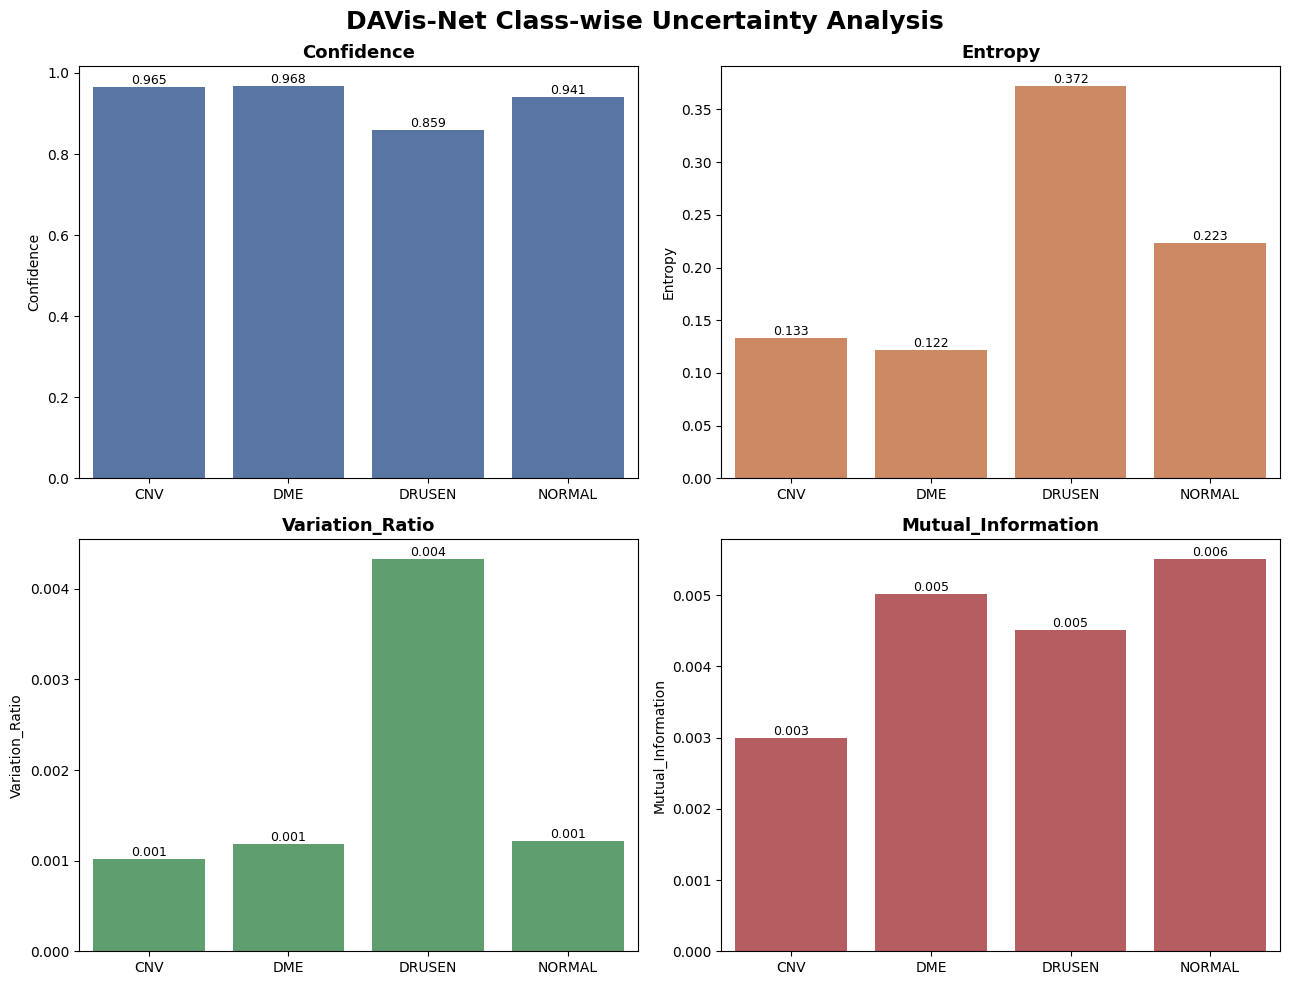

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = classwise_summary.copy()

metrics = ["Confidence", "Entropy", "Variation_Ratio", "Mutual_Information"]

fig, axes = plt.subplots(2, 2, figsize=(13,10))
axes = axes.flatten()

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for ax, metric, color in zip(axes, metrics, colors):
    sns.barplot(data=plot_df, x="true_class", y=metric, color=color, ax=ax)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=9)

    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.set_title(metric, fontsize=13, fontweight="bold")

plt.suptitle("DAVis-Net Class-wise Uncertainty Analysis", fontsize=18, fontweight="bold")
plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "classwise_uncertainty_comparison.png"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_58/1012817511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=uq_df, x="Correct", y=m, ax=ax, palette=["#d9534f", "#5cb85c"])
/tmp/ipykernel_58/1012817511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=uq_df, x="Correct", y=m, ax=ax, palette=["#d9534f", "#5cb85c"])
/tmp/ipykernel_58/1012817511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=uq_df, x="Correct", y=m, ax=ax, palette=["#d9534f", "#5cb85c"])
/tmp/ipykernel_58/1012817511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is 

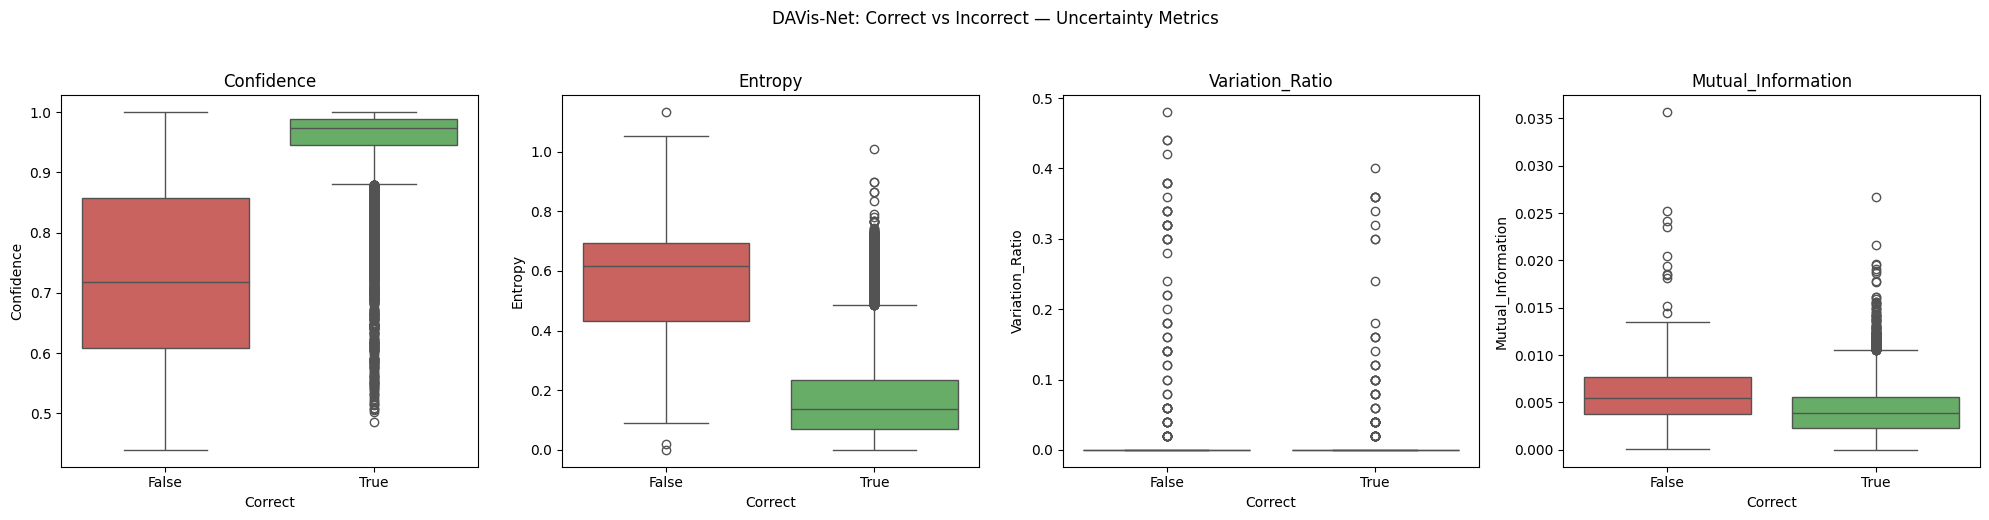

In [11]:
fig, axes = plt.subplots(1, len(metrics), figsize=(5*len(metrics), 5))
for ax, m in zip(axes, metrics):
    sns.boxplot(data=uq_df, x="Correct", y=m, ax=ax, palette=["#d9534f", "#5cb85c"])
    ax.set_title(m)
    ax.set_xlabel("Correct")
plt.suptitle("DAVis-Net: Correct vs Incorrect — Uncertainty Metrics", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "boxplots_correct_vs_incorrect.png"), dpi=600, bbox_inches="tight")
plt.show()

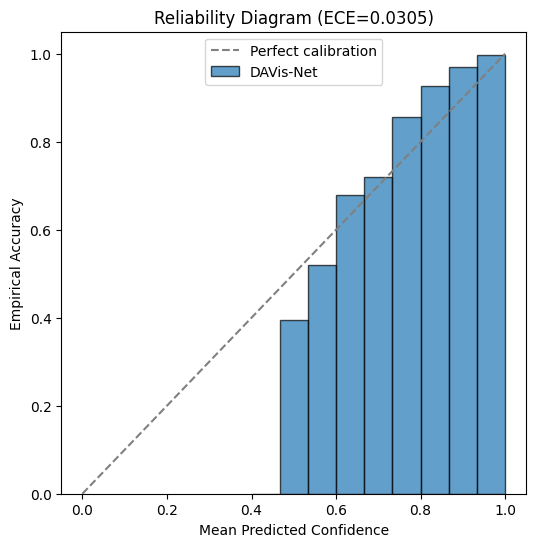

ECE (MC Dropout mean-prob, pre-temp-scaling): 0.030531715710643725


In [12]:
def reliability_diagram(confidences, correctness, n_bins=15, save_path=None):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_acc, bin_conf, bin_count = [], [], []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() > 0:
            bin_acc.append(correctness[mask].mean())
            bin_conf.append(confidences[mask].mean())
            bin_count.append(mask.sum())
        else:
            bin_acc.append(np.nan); bin_conf.append(np.nan); bin_count.append(0)

    ece = np.nansum([bin_count[i]/len(confidences) * abs(bin_acc[i]-bin_conf[i])
                      for i in range(n_bins) if bin_count[i] > 0])

    plt.figure(figsize=(6,6))
    plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Perfect calibration")
    plt.bar(bins[:-1], bin_acc, width=1/n_bins, align="edge", alpha=0.7,
            edgecolor="black", label="DAVis-Net")
    plt.xlabel("Mean Predicted Confidence")
    plt.ylabel("Empirical Accuracy")
    plt.title(f"Reliability Diagram (ECE={ece:.4f})")
    plt.legend()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")
    plt.show()
    return ece

ece_uncalibrated = reliability_diagram(uq_df["Confidence"].values, uq_df["Correct"].values,
                                        save_path=os.path.join(OUT_DIR, "reliability_diagram.png"))
print("ECE (MC Dropout mean-prob, pre-temp-scaling):", ece_uncalibrated)

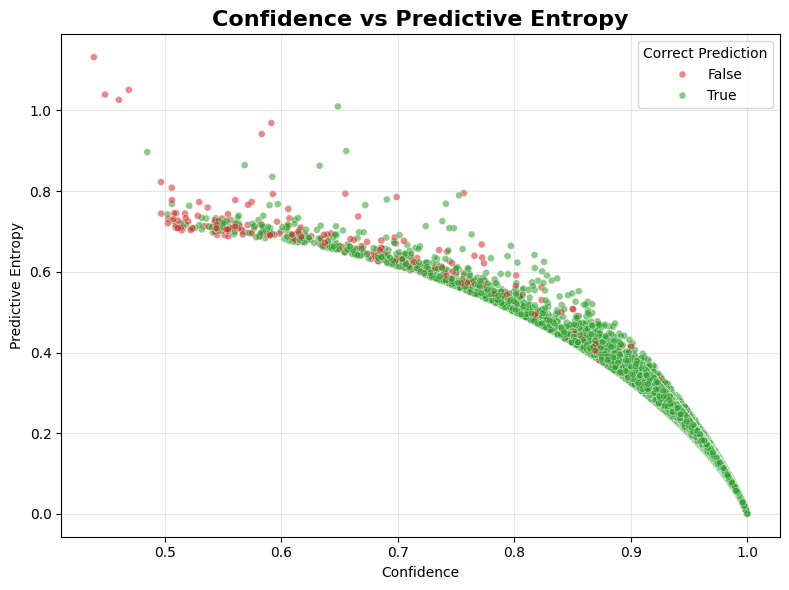

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=uq_df, x="Confidence", y="Entropy", hue="Correct", alpha=0.55, s=25,
                palette={True:"#2ca02c", False:"#d62728"}
               )

plt.title("Confidence vs Predictive Entropy", fontsize=16, fontweight="bold")
plt.xlabel("Confidence")
plt.ylabel("Predictive Entropy")
plt.grid(alpha=0.3)
plt.legend(title="Correct Prediction")
plt.tight_layout()

plt.savefig(os.path.join(OUT_DIR, "confidence_vs_entropy.png"),
            dpi=600,
            bbox_inches="tight"
           )

plt.show()

In [14]:
drusen_df = uq_df[uq_df.true_class == "DRUSEN"].copy()

drusen_correct_incorrect = drusen_df.groupby("Correct")[metrics].mean()
print("DRUSEN correct vs incorrect:\n", drusen_correct_incorrect)

# Misclassification targets
misclass = drusen_df.loc[~drusen_df.Correct, "pred_class"].value_counts()
print("\nDRUSEN misclassified -> predicted as:\n", misclass)

misclass_conf = drusen_df.loc[~drusen_df.Correct].groupby("pred_class")[["Confidence","Entropy","Mutual_Information"]].mean()
print("\nMisclassification metrics by predicted class:\n", misclass_conf)

# ROC-AUC: using each metric to distinguish correct vs incorrect DRUSEN predictions
y_true_err = (~drusen_df["Correct"]).astype(int)  # 1 = error
roc_results = {}
for m, higher_is_error in [("Entropy", True), ("Variation_Ratio", True),
                           ("Mutual_Information", True), ("Confidence", False)]:
    score = drusen_df[m] if higher_is_error else -drusen_df[m]
    auc = roc_auc_score(y_true_err, score)
    roc_results[m if m != "Confidence" else "Inverse Confidence"] = auc

print("\nDRUSEN ROC-AUC for error detection:")
for k, v in roc_results.items():
    print(f"{k}: {v:.4f}")

with open(os.path.join(OUT_DIR, "drusen_uncertainty_analysis.json"), "w") as f:
    json.dump({
        "correct_vs_incorrect": drusen_correct_incorrect.to_dict(),
        "misclassification_targets": misclass.to_dict(),
        "roc_auc_error_detection": roc_results
    }, f, indent=2, default=str)

drusen_df.to_csv(os.path.join(OUT_DIR, "drusen_uncertainty_detail.csv"), index=False)

DRUSEN correct vs incorrect:
          Confidence   Entropy  Variation_Ratio  Mutual_Information
Correct                                                           
False      0.750411  0.540165          0.03165            0.007087
True       0.867645  0.358113          0.00202            0.004297

DRUSEN misclassified -> predicted as:
 pred_class
NORMAL    49
CNV       46
DME        8
Name: count, dtype: int64

Misclassification metrics by predicted class:
             Confidence   Entropy  Mutual_Information
pred_class                                          
CNV           0.746111  0.541853            0.006539
DME           0.752052  0.596811            0.018554
NORMAL        0.754179  0.529331            0.005729

DRUSEN ROC-AUC for error detection:
Entropy: 0.7493
Variation_Ratio: 0.5886
Mutual_Information: 0.7580
Inverse Confidence: 0.7276


In [15]:
y_true = (~drusen_df["Correct"]).astype(int)
thresholds = np.arange(0, drusen_df["Entropy"].max(), 0.01)
results = []
for thr in thresholds:
    y_pred = (drusen_df["Entropy"] > thr).astype(int)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    results.append({"Threshold": thr, "Precision": p, "Recall": r, "F1": f1})

threshold_df = pd.DataFrame(results)
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
print(best_row)
threshold_df.to_csv(os.path.join(OUT_DIR, "drusen_threshold_analysis.csv"), index=False)

Threshold    0.670000
Precision    0.389474
Recall       0.359223
F1           0.373737
Name: 67, dtype: float64


### Part B: Explainablity Analysis

In [21]:
class CAMBase:
    def __init__(self, model, target_layer_name="cbam2"):
        self.model = model
        self.target_layer = getattr(model, target_layer_name)
        self.activations = None
        self.gradients = None
        self.target_layer.register_forward_hook(self._save_activation)

    def _save_activation(self, module, inp, out):
        self.activations = out

    def _save_gradient(self, grad):
        self.gradients = grad

    def _forward(self, x, class_idx=None):
        self.model.eval()
        main_out, _, _, _ = self.model(x, return_features=True)
        if class_idx is None:
            class_idx = main_out.argmax(dim=1)
        return main_out, class_idx


class GradCAM(CAMBase):
    def generate(self, x, class_idx=None):
        x = x.clone().requires_grad_(True)
        main_out, class_idx = self._forward(x, class_idx)
        self.activations.register_hook(self._save_gradient)
        score = main_out.gather(1, class_idx.view(-1,1)).sum()
        self.model.zero_grad()
        score.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2,3), keepdim=True)          # GAP over grads
        cam = F.relu((weights * self.activations).sum(dim=1))
        cam = F.interpolate(cam.unsqueeze(1), size=x.shape[2:], mode="bilinear", align_corners=False).squeeze(1)
        cam = cam - cam.amin(dim=(1,2), keepdim=True)
        cam = cam / (cam.amax(dim=(1,2), keepdim=True) + 1e-8)
        return cam.detach().cpu().numpy(), main_out.detach(), class_idx


class GradCAMPlusPlus(CAMBase):
    def generate(self, x, class_idx=None):
        x = x.clone().requires_grad_(True)
        main_out, class_idx = self._forward(x, class_idx)
        self.activations.register_hook(self._save_gradient)
        score = main_out.gather(1, class_idx.view(-1,1)).sum()
        self.model.zero_grad()
        score.backward(retain_graph=True)

        grads = self.gradients
        acts = self.activations
        grads2 = grads ** 2
        grads3 = grads ** 3
        sum_acts = acts.sum(dim=(2,3), keepdim=True)
        alpha_denom = 2*grads2 + sum_acts*grads3 + 1e-8
        alpha = grads2 / alpha_denom
        weights = (alpha * F.relu(grads)).sum(dim=(2,3), keepdim=True)

        cam = F.relu((weights * acts).sum(dim=1))
        cam = F.interpolate(cam.unsqueeze(1), size=x.shape[2:], mode="bilinear", align_corners=False).squeeze(1)
        cam = cam - cam.amin(dim=(1,2), keepdim=True)
        cam = cam / (cam.amax(dim=(1,2), keepdim=True) + 1e-8)
        return cam.detach().cpu().numpy(), main_out.detach(), class_idx


class ScoreCAM(CAMBase):

    @torch.no_grad()
    def generate(self, x, class_idx=None, batch_size=64):
        main_out, class_idx = self._forward(x, class_idx)
        acts = self.activations

        B, C, h, w = acts.shape
        H, W = x.shape[2:]

        cams = []

        for b in range(B):
            act_maps = F.interpolate(
                acts[b:b+1],
                size=(H, W),
                mode="bilinear",
                align_corners=False
            )[0]

            act_min = act_maps.amin(dim=(1,2), keepdim=True)
            act_max = act_maps.amax(dim=(1,2), keepdim=True)

            act_maps = (act_maps-act_min)/(act_max-act_min+1e-8)

            weights = []

            for start in range(0, C, batch_size):
                end = min(start+batch_size, C)
                masks = act_maps[start:end].unsqueeze(1)
                masked_imgs = x[b:b+1] * masks
                out,_ = self.model(masked_imgs)
                probs = F.softmax(out,dim=1)
                weights.append(probs[:,class_idx[b]])

            weights = torch.cat(weights)
            weights = F.softmax(weights,dim=0)
            cam = (weights[:,None,None]*act_maps).sum(0)
            cam = F.relu(cam)
            cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
            cams.append(cam)

        cams = torch.stack(cams)
        return cams.cpu().numpy(), main_out, class_idx


gradcam = GradCAM(model, "cbam2")
gradcampp = GradCAMPlusPlus(model, "cbam2")
scorecam = ScoreCAM(model, "cbam2")

In [22]:
def denorm(x):
    mean = torch.tensor(IMAGENET_MEAN, device=x.device).view(1,3,1,1)
    std  = torch.tensor(IMAGENET_STD, device=x.device).view(1,3,1,1)
    return x * std + mean

@torch.no_grad()
def get_confidence(model, x, class_idx):
    out, _ = model(x)
    probs = F.softmax(out, dim=1)
    return probs.gather(1, class_idx.view(-1,1)).squeeze(1)

@torch.no_grad()
def average_drop_increase_conf(model, x, cam, class_idx):
    orig_conf = get_confidence(model, x, class_idx)
    cam_t = torch.tensor(cam, device=x.device).unsqueeze(1)  # [B,1,H,W]
    masked_x = x * cam_t
    masked_conf = get_confidence(model, masked_x, class_idx)

    drop = F.relu(orig_conf - masked_conf) / (orig_conf + 1e-8) * 100
    increase = (masked_conf > orig_conf).float() * 100
    return drop.mean().item(), increase.mean().item()

@torch.no_grad()
def deletion_insertion_auc(model, x, cam, class_idx, steps=20):
    B, C, H, W = x.shape
    n_pixels = H * W
    cam_flat = torch.tensor(cam, device=x.device).view(B, -1)
    order = cam_flat.argsort(dim=1, descending=True)  # most important first

    baseline = torch.zeros_like(x)  # blank image
    del_scores, ins_scores = [], []

    for frac in np.linspace(0, 1, steps):
        k = int(frac * n_pixels)
        del_x = x.clone().view(B, C, -1)
        ins_x = baseline.clone().view(B, C, -1)
        for b in range(B):
            idx = order[b, :k]
            del_x[b, :, idx] = 0.0
            ins_x[b, :, idx] = x.view(B, C, -1)[b, :, idx]
        del_x = del_x.view(B, C, H, W)
        ins_x = ins_x.view(B, C, H, W)

        del_scores.append(get_confidence(model, del_x, class_idx).cpu().numpy())
        ins_scores.append(get_confidence(model, ins_x, class_idx).cpu().numpy())

    del_scores = np.stack(del_scores)  # [steps, B]
    ins_scores = np.stack(ins_scores)
    del_auc = np.trapezoid(del_scores, dx=1/steps, axis=0)
    ins_auc = np.trapezoid(ins_scores, dx=1/steps, axis=0)
    return del_auc.mean(), ins_auc.mean()

def road_score(cam, deletion_auc):
    # ROAD proxy: lower is better (faster confidence collapse under importance-order deletion)
    return deletion_auc

In [24]:
def build_xai_subset(dataset, labels, sample_size):
    if sample_size is None:
        return list(range(len(labels)))
    idxs = []
    for c in range(len(CLASSES)):
        class_idxs = np.where(labels == c)[0]
        n = min(sample_size, len(class_idxs))
        idxs.extend(np.random.choice(class_idxs, n, replace=False))
    return idxs

xai_idxs = build_xai_subset(test_dataset, all_labels, XAI_SAMPLE_SIZE)
xai_subset = Subset(test_dataset, xai_idxs)
xai_loader = DataLoader(xai_subset, batch_size=8, shuffle=False)

methods = {"GradCAM": gradcam, "GradCAM++": gradcampp, "ScoreCAM": scorecam}
per_method_results = {m: [] for m in methods}
per_method_per_class = {m: {c: [] for c in CLASSES} for m in methods}

for x, y in xai_loader:
    x = x.to(device)
    y = y.to(device)
    for mname, cam_fn in methods.items():
        cam, main_out, class_idx = cam_fn.generate(x, class_idx=y)
        drop, inc = average_drop_increase_conf(model, x, cam, class_idx)
        del_auc, ins_auc = deletion_insertion_auc(model, x, cam, class_idx, steps=10)
        road = road_score(cam, del_auc)

        per_method_results[mname].append({
            "Average_Drop": drop, "Increase_Confidence": inc,
            "Deletion_AUC": del_auc, "Insertion_AUC": ins_auc, "ROAD": road
        })
        for i, lbl in enumerate(y.cpu().numpy()):
            per_method_per_class[mname][CLASSES[lbl]].append(cam[i])

# Aggregate overall method comparison table
method_summary = []
for mname, results in per_method_results.items():
    df = pd.DataFrame(results)
    method_summary.append({"Method": mname, **df.mean().to_dict()})
method_summary_df = pd.DataFrame(method_summary)
method_summary_df.to_csv(os.path.join(OUT_DIR, "xai_method_comparison.csv"), index=False)
method_summary_df

,Method,Average_Drop,Increase_Confidence,Deletion_AUC,Insertion_AUC,ROAD
0,GradCAM,7.314386,12.00,0.351806,0.775962,0.351806
1,GradCAM++,7.447525,12.50,0.355450,0.774882,0.355450
2,ScoreCAM,7.623805,17.25,0.362041,0.758529,0.362041


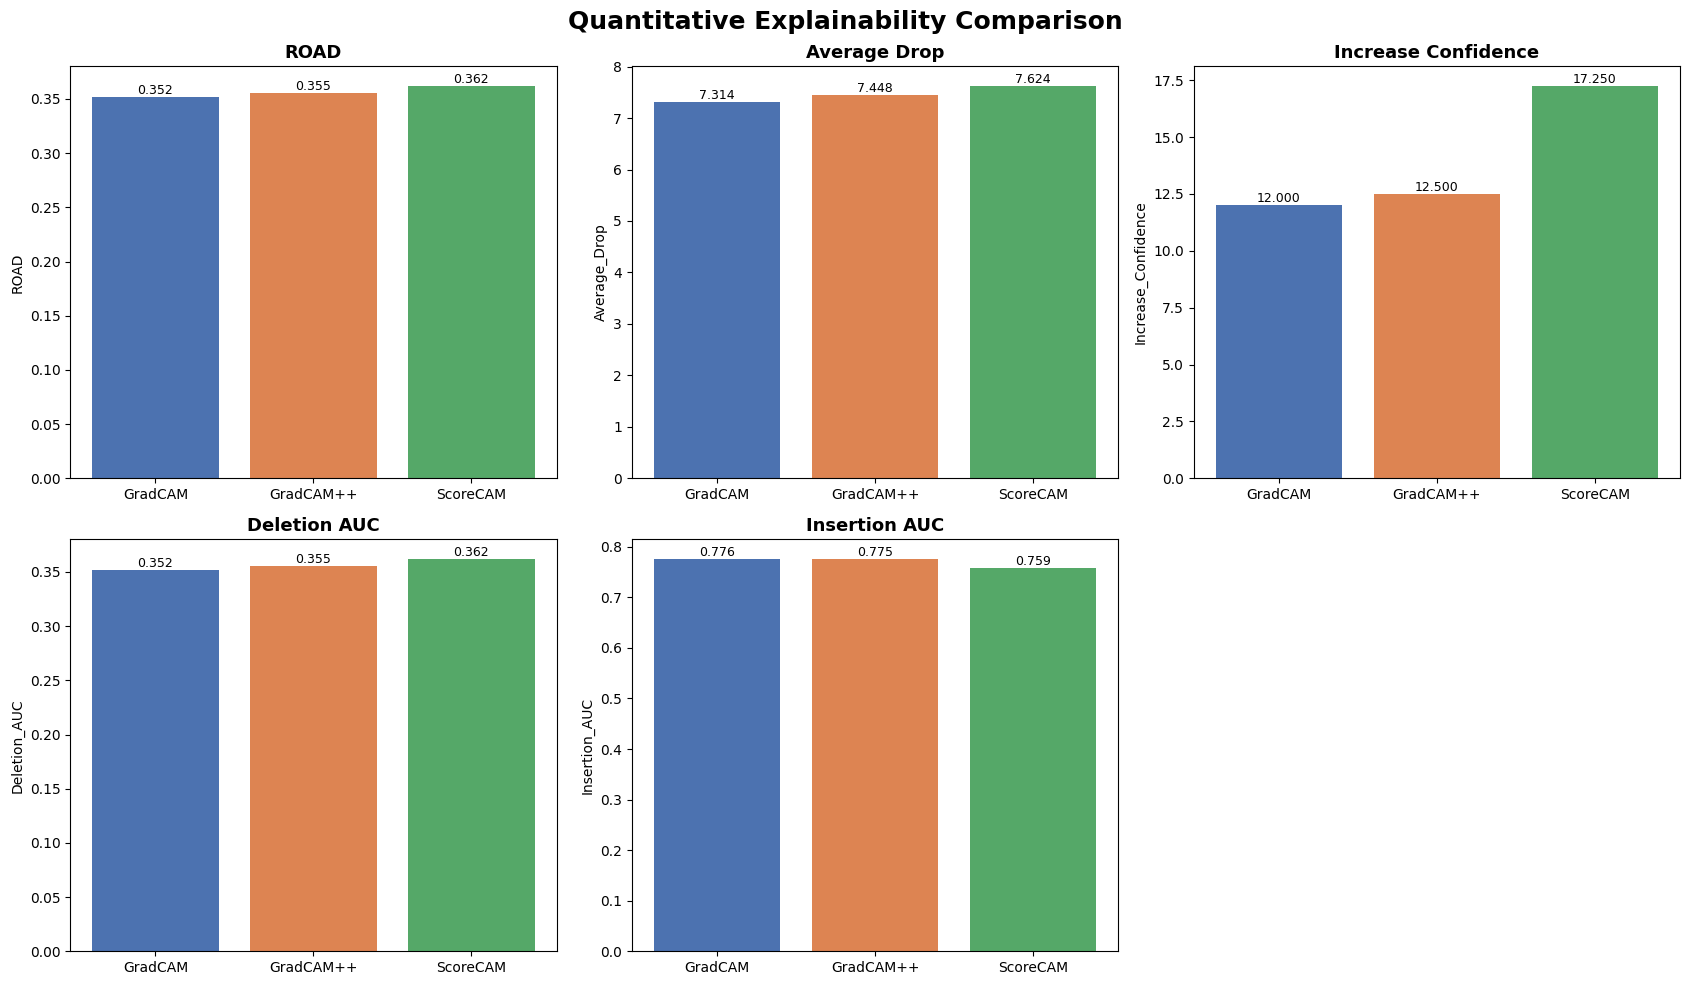

In [25]:
plot_df = method_summary_df.copy()

metrics = [
    "ROAD", 
    "Average_Drop",
    "Increase_Confidence",
    "Deletion_AUC",
    "Insertion_AUC"
]

titles = ["ROAD", "Average Drop", "Increase Confidence", "Deletion AUC", "Insertion AUC"]
fig, axes = plt.subplots(2, 3, figsize=(17,10))
axes = axes.flatten()

colors = ["#4C72B0", "#DD8452", "#55A868"]

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    bars = ax.bar(plot_df["Method"], plot_df[metric], color=colors)
    ax.set_title(titles[idx], fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h, f"{h:.3f}",
                ha="center", va="bottom", fontsize=9)

axes[-1].axis("off")
plt.suptitle("Quantitative Explainability Comparison", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "quantitative_xai_comparison.png"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [26]:
def mean_pairwise_cosine(cam_list, max_pairs=500):
    flat = [c.flatten() for c in cam_list]
    n = len(flat)
    if n < 2:
        return np.nan
    pairs = [(i,j) for i in range(n) for j in range(i+1, n)]
    if len(pairs) > max_pairs:
        pairs = random.sample(pairs, max_pairs)
    sims = []
    for i, j in pairs:
        a, b = flat[i], flat[j]
        sim = np.dot(a,b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-8)
        sims.append(sim)
    return np.mean(sims)

consistency_table = {}
for mname in methods:
    consistency_table[mname] = {}
    for c in CLASSES:
        consistency_table[mname][c] = mean_pairwise_cosine(per_method_per_class[mname][c])

consistency_df = pd.DataFrame(consistency_table).T
consistency_df.to_csv(os.path.join(OUT_DIR, "xai_classwise_cosine_consistency.csv"))
print(consistency_df)

                CNV       DME    DRUSEN    NORMAL
GradCAM    0.645130  0.697294  0.688894  0.747293
GradCAM++  0.661374  0.699565  0.721727  0.757302
ScoreCAM   0.748418  0.724886  0.781732  0.828349


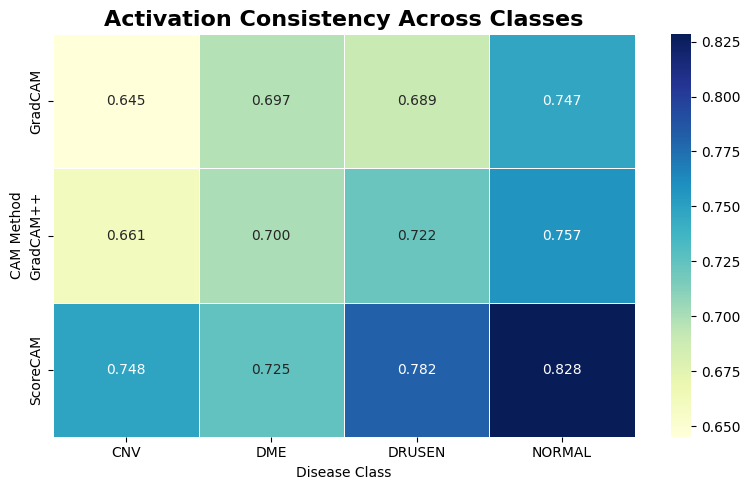

In [27]:
plt.figure(figsize=(8,5))

sns.heatmap(consistency_df, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=.5, cbar=True)
plt.title("Activation Consistency Across Classes", fontsize=16, fontweight="bold")
plt.xlabel("Disease Class")
plt.ylabel("CAM Method")
plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "activation_consistency_heatmap.png"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

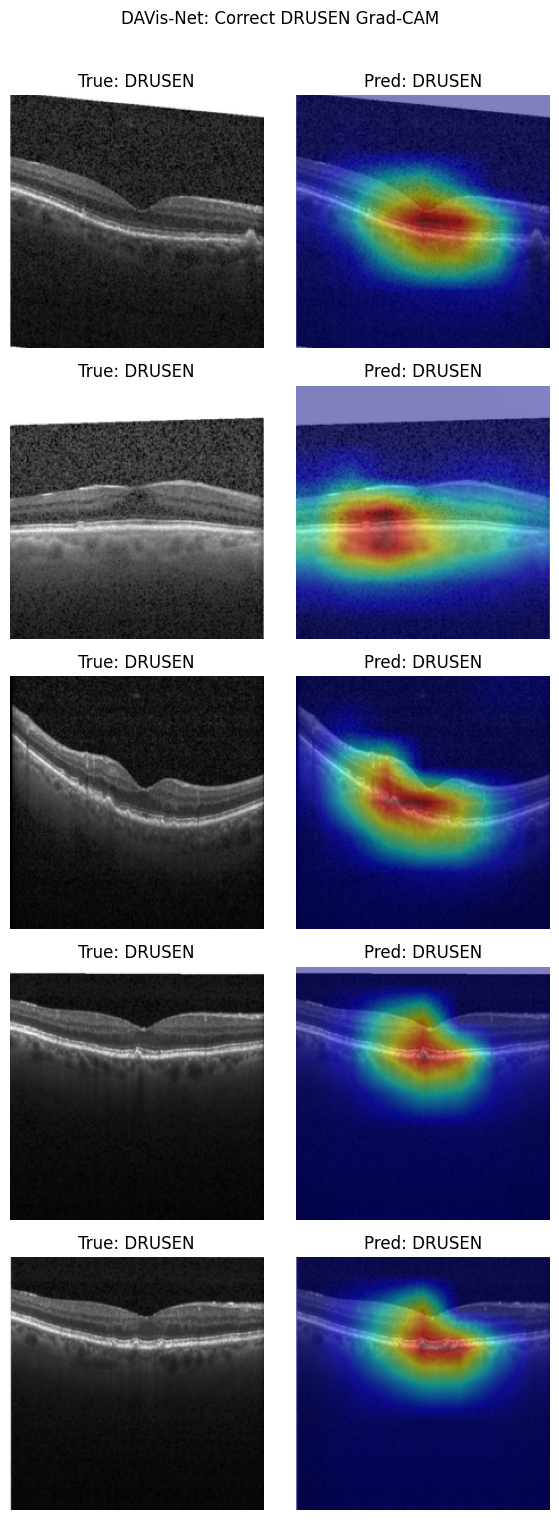

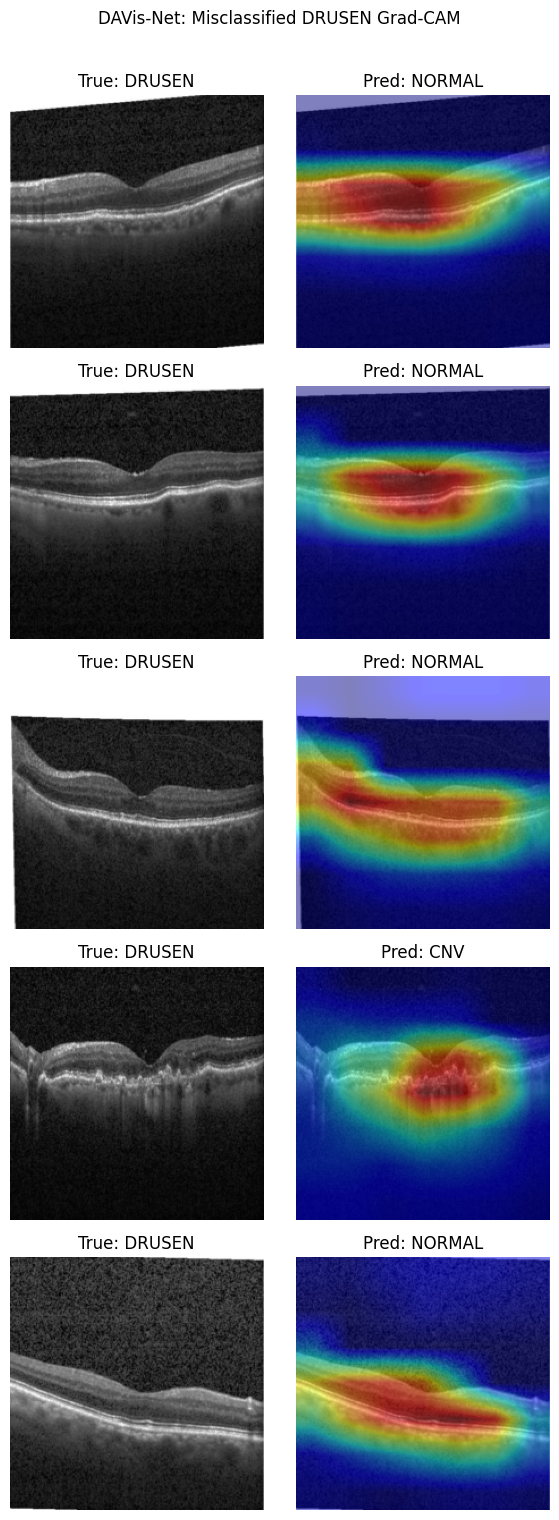

In [28]:
def get_display_image(dataset_idx):
    path = all_paths[dataset_idx]
    img_t, _ = test_dataset[dataset_idx]
    img_disp = denorm(img_t.unsqueeze(0).to(device))[0].permute(1,2,0).cpu().numpy()
    return np.clip(img_disp, 0, 1)

@torch.no_grad()
def model_predict_single(idx):
    x, y = test_dataset[idx]
    x = x.unsqueeze(0).to(device)
    out, _ = model(x)
    pred = out.argmax(dim=1).item()
    return x, y, pred

drusen_indices = np.where(all_labels == DRUSEN_IDX)[0]
correct_drusen = [i for i in drusen_indices if model_predict_single(i)[2] == DRUSEN_IDX][:5]
misclassified_drusen = [i for i in drusen_indices if model_predict_single(i)[2] != DRUSEN_IDX][:5]

def plot_gradcam_gallery(indices, title, filename):
    fig, axes = plt.subplots(len(indices), 2, figsize=(6, 3*len(indices)))
    if len(indices) == 1:
        axes = axes.reshape(1,-1)
    for row, idx in enumerate(indices):
        x, y, pred = model_predict_single(idx)
        cam, _, class_idx = gradcam.generate(x, class_idx=torch.tensor([pred], device=device))
        img = get_display_image(idx)

        axes[row,0].imshow(img); axes[row,0].set_title(f"True: {CLASSES[y]}"); axes[row,0].axis("off")
        axes[row,1].imshow(img); axes[row,1].imshow(cam[0], cmap="jet", alpha=0.5)
        axes[row,1].set_title(f"Pred: {CLASSES[pred]}"); axes[row,1].axis("off")
    plt.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, filename), dpi=600, bbox_inches="tight")
    plt.show()

plot_gradcam_gallery(correct_drusen, "DAVis-Net: Correct DRUSEN Grad-CAM", "davisnet_correct_drusen_gradcam.png")
plot_gradcam_gallery(misclassified_drusen, "DAVis-Net: Misclassified DRUSEN Grad-CAM", "davisnet_misclassified_drusen_gradcam.png")

In [29]:
def central_roi_energy_ratio(cam, roi_frac=0.5):
    H, W = cam.shape
    h0, h1 = int(H*(1-roi_frac)/2), int(H*(1+roi_frac)/2)
    w0, w1 = int(W*(1-roi_frac)/2), int(W*(1+roi_frac)/2)
    central_energy = cam[h0:h1, w0:w1].sum()
    total_energy = cam.sum() + 1e-8
    return central_energy / total_energy

localization_scores = []
for idx in drusen_indices:
    x, y, pred = model_predict_single(idx)
    cam, _, _ = gradcam.generate(x, class_idx=torch.tensor([pred], device=device))
    score = central_roi_energy_ratio(cam[0])
    localization_scores.append({"idx": idx, "Correct": pred == DRUSEN_IDX, "localization_score": score})

loc_df = pd.DataFrame(localization_scores)
loc_df.to_csv(os.path.join(OUT_DIR, "davisnet_drusen_localization_scores.csv"), index=False)

grp_correct = loc_df.loc[loc_df.Correct, "localization_score"]
grp_incorrect = loc_df.loc[~loc_df.Correct, "localization_score"]
stat, p = mannwhitneyu(grp_correct, grp_incorrect, alternative="two-sided")
print(f"Localization score, correct vs. misclassified DRUSEN (Mann-Whitney): p={p:.4f}")

Localization score, correct vs. misclassified DRUSEN (Mann-Whitney): p=0.0000


In [35]:
loc_df.groupby("Correct")["localization_score"].describe()
loc_df.groupby("Correct")["localization_score"].mean()

Correct
False    0.545460
True     0.636742
Name: localization_score, dtype: float32

/tmp/ipykernel_58/336085245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=loc_df, x="Correct", y="localization_score",


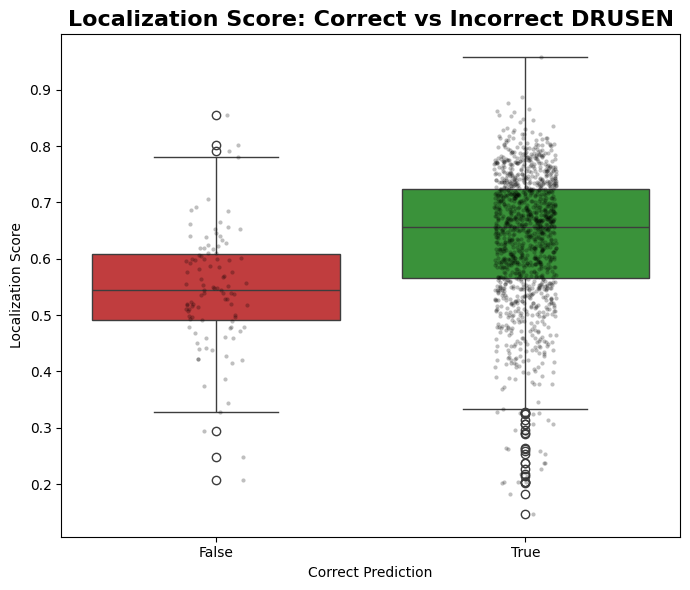

In [32]:
plt.figure(figsize=(7,6))

sns.boxplot(data=loc_df, x="Correct", y="localization_score",
            palette={'True':"#2ca02c", 'False':"#d62728"}
           )

sns.stripplot(data=loc_df, x="Correct", y="localization_score", 
              color="black", alpha=0.25, size=3)

plt.title("Localization Score: Correct vs Incorrect DRUSEN", fontsize=16, fontweight="bold")
plt.xlabel("Correct Prediction")
plt.ylabel("Localization Score")
plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "localization_score_boxplot.png"),
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [33]:
final_xai_summary = {
    "method_comparison": method_summary_df.to_dict(orient="records"),
    "classwise_cosine_consistency": consistency_df.to_dict(),
    "drusen_localization_mannwhitney_p": p,
}
with open(os.path.join(OUT_DIR, "davisnet_xai_summary.json"), "w") as f:
    json.dump(final_xai_summary, f, indent=2, default=str)

print("All DAVis-Net Uncertainty + Explainability outputs saved to:", OUT_DIR)

All DAVis-Net Uncertainty + Explainability outputs saved to: /kaggle/working/davisnet_xai_uq


In [36]:
!zip -r /kaggle/working/davisnet_xai_uq_results.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/davisnet_xai_uq/ (stored 0%)
  adding: kaggle/working/davisnet_xai_uq/davisnet_correct_drusen_gradcam.png (deflated 14%)
  adding: kaggle/working/davisnet_xai_uq/correct_vs_incorrect_summary.csv (deflated 24%)
  adding: kaggle/working/davisnet_xai_uq/mc_probs.npy (deflated 6%)
  adding: kaggle/working/davisnet_xai_uq/significance_tests.csv (deflated 25%)
  adding: kaggle/working/davisnet_xai_uq/xai_classwise_cosine_consistency.csv (deflated 29%)
  adding: kaggle/working/davisnet_xai_uq/localization_score_boxplot.png (deflated 17%)
  adding: kaggle/working/davisnet_xai_uq/quantitative_xai_comparison.png (deflated 39%)
  adding: kaggle/working/davisnet_xai_uq/classwise_uncertainty_comparison.png (deflated 37%)
  adding: kaggle/working/davisnet_xai_uq/activation_consistency_heatmap.png (deflated 21%)
  adding: kaggle/working/davisnet_xai_uq/reliability_diagram.png (deflated 24%)
  adding: kaggle/working/davisnet_xai_uq/davisne